# E-Commerce User Funnel Analysis

## Objective
Analyze user behavior and conversion funnel using event-level data.

## Tools
- Phyton
- Pandas
- Matplotlib

In [724]:
import pandas as pd

In [701]:
df = pd.read_excel('/content/Dataset Case Study.xlsx')

In [702]:
df.head()

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel
0,9bd8725f-5722-41b7-8d95-a5dafec33a56,482c0ae4-ac6c-4eb3-91fe-b0e63c1c2a5d,98b232db-5bec-41d8-88e1-5d2e98899e29,product_view,2025-09-22 16:35:26.996,P1208,US,IOS,paid_search
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:03.996,NaN,ID,android,referral
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:50.996,NaN,AU,IOS,paid_search
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:32.996,NaN,VN,IOS,organic
4,26dcc5fa-334c-420c-be1e-a40eb4b9efac,f9aee3bb-2ba4-4bb3-9eec-44ba4664f93b,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,product_view,2025-07-02 12:19:22.996,P1315,ID,desktop,social


In [703]:
df.columns

Index(['event_id', 'user_id', 'session_id', 'event_type', 'event_timestamp',
       'product_id', 'country', 'device', 'channel'],
      dtype='object')

In [704]:
df.shape

(10000, 9)

In [705]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

In [706]:
df['month'] = df['event_timestamp'].dt.to_period('M')

In [707]:
q2 = df[(df['event_timestamp']>= '2025-04-01') & (df['event_timestamp']<= '2025-06-30')]
q2.head()

,event_id,user_id,session_id,event_type,event_timestamp,product_id,country,device,channel,month
1,f6dc704c-a88c-4668-b89d-e6b08e7e02d4,ff6c808d-fa75-4202-801f-a076299a2c0f,d4832af2-0aad-489c-8eb6-22d243f5f5c4,page_view,2025-06-04 21:55:03.996,NaN,ID,android,referral,2025-06
2,abb69be8-df83-420b-92f7-149d29a6d32f,78ea2c10-e824-4b3c-b74b-cdb0cbab0610,1f6c5b12-6c79-4b29-bae6-878804723e55,page_view,2025-06-24 02:02:50.996,NaN,AU,IOS,paid_search,2025-06
3,76fd2399-0f80-4184-8802-90dac9bf52d3,9c63419c-b3dc-44a6-b8a5-a438e82afee8,ed1c4ded-cf67-463e-b94f-4cebcf62d827,page_view,2025-06-05 12:35:32.996,NaN,VN,IOS,organic,2025-06
6,c8073c50-01d3-4683-983a-3d1383c173d4,bb36401f-3a29-4868-b34d-ad8a9ce6f8dd,6cbc0241-d60c-4c88-a2f2-b6abc6a6231c,product_view,2025-05-03 09:27:42.996,P1192,SG,android,direct,2025-05
7,d74091e8-38e9-434c-be25-537b442df825,bc073178-e3c6-4701-bedc-6efb6007a28a,8dbbfa2a-8e8c-46e3-b959-81ea46697a16,login,2025-05-02 05:35:31.996,NaN,ID,IOS,organic,2025-05


In [708]:
country_active = q2.groupby('country')['user_id'].nunique()
country_active

,user_id
country,
AU,215
ID,1045
MY,458
PH,461
SG,457
TH,234
US,810
VN,482


In [709]:
country_active = q2.groupby('country')['user_id'].nunique().astype(int)
country_active = country_active.sort_values()
country_active

,user_id
country,
AU,215
TH,234
SG,457
MY,458
PH,461
VN,482
US,810
ID,1045


<Axes: title={'center': 'Active Users by Country Q2 2025'}, xlabel='country'>

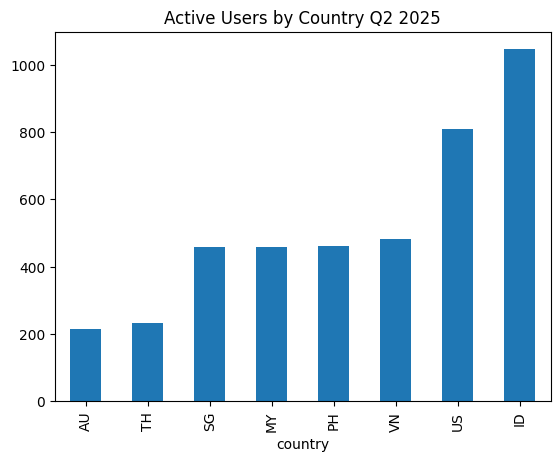

In [710]:
country_active.plot(kind='bar',title='Active Users by Country Q2 2025')

- Indonesia has the highest active users during Q2 2025
- Meanwhile Australia is the lowest active users during Q2 2025

In [711]:
mau=(df.groupby(['month','channel'])['user_id'].nunique().reset_index())
mau

,month,channel,user_id
0,2025-03,direct,41
1,2025-03,email,33
2,2025-03,organic,34
3,2025-03,paid_search,38
4,2025-03,referral,50
5,2025-03,social,40
6,2025-04,direct,262
7,2025-04,email,258
8,2025-04,organic,260
9,2025-04,paid_search,255


In [712]:
mau_pivot = mau.pivot(index='month',columns='channel',values='user_id')
mau_pivot

channel,direct,email,organic,paid_search,referral,social
month,,,,,,
2025-03,41,33,34,38,50,40
2025-04,262,258,260,255,244,276
2025-05,270,284,251,259,244,268
2025-06,271,263,259,258,289,262
2025-07,257,290,268,288,255,250
2025-08,250,248,249,251,292,240
2025-09,186,209,208,206,197,174


<Axes: title={'center': 'Monthly Active User by Channel'}, xlabel='month'>

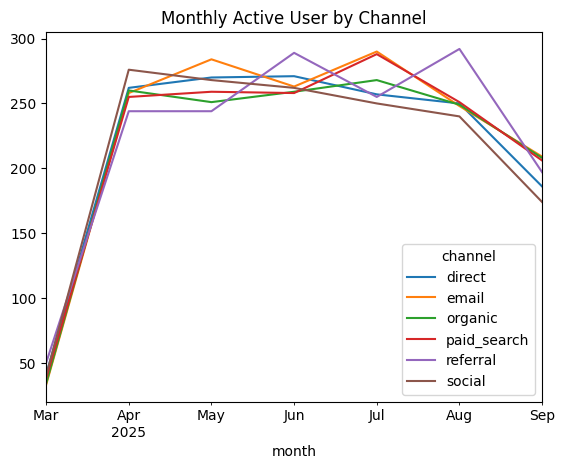

In [713]:
mau_pivot.plot(kind='line',title='Monthly Active User by Channel')

Refferal channel shows the strongest monthly user growth.

In [714]:
device_session = (df[['session_id','device']].drop_duplicates())
device_session

,session_id,device
0,98b232db-5bec-41d8-88e1-5d2e98899e29,IOS
1,d4832af2-0aad-489c-8eb6-22d243f5f5c4,android
2,1f6c5b12-6c79-4b29-bae6-878804723e55,IOS
3,ed1c4ded-cf67-463e-b94f-4cebcf62d827,IOS
4,9a469fb9-6cf4-4818-b0a6-7302b0bd665a,desktop
...,...,...
9995,d7f295f5-1ae0-4498-9f99-4e2f0667738e,desktop
9996,32a5813f-5ad4-47b2-8665-17d2b0712bc3,IOS
9997,61a8fb5a-662d-4df2-b43d-a4a3705f8a7c,IOS
9998,66747072-cc0e-4c17-9604-5dacfa48da78,android


In [715]:
device_count = (
    device_session
    .groupby('device')['session_id']
    .count()
    .sort_values(ascending=False)
)
device_count

,session_id
device,
android,4961
IOS,4000
desktop,1039


<Axes: title={'center': 'Session by Device'}, xlabel='device'>

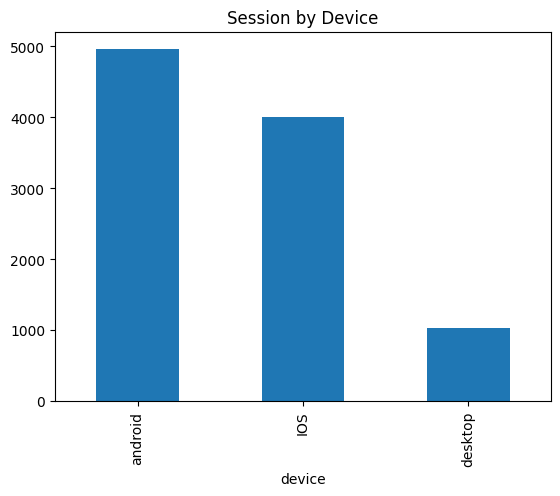

In [716]:
device_count.plot(kind='bar',title='Session by Device')

Android contribute the majority of sessions

In [717]:
search = df[df['event_type']=='search'][['user_id','event_timestamp']]
search.head()

,user_id,event_timestamp
10,25086909-bab6-4d11-b3c9-a1c5d40bb45e,2025-08-26 01:44:34.996
23,49558737-2006-4c3d-9888-27b9d83961e3,2025-05-09 18:53:59.996
27,2222582c-c461-41ff-8173-6a10567f29bc,2025-08-15 17:04:46.996
35,30cf46ff-63c5-449a-8daa-77ba66879441,2025-04-07 04:28:36.996
43,3c6bb5a7-f025-4557-83f7-c809e60df6e2,2025-08-29 10:12:59.996


In [718]:
atc = df[df['event_type']=='add_to_cart'][['user_id','event_timestamp']]
atc.head()

,user_id,event_timestamp
12,f77399ba-5fb9-4da7-8cc0-56196dfe997f,2025-07-27 03:41:43.996
13,c9d6ea82-cbd3-4f1b-ad19-c0a1d670c188,2025-04-18 09:22:57.996
32,ff8ad71f-1de6-4d4d-a087-822045cd78a1,2025-07-04 00:45:23.996
40,51bbab46-1d07-4000-a961-c8f54c3eaf32,2025-06-16 16:55:48.996
53,3d1fd90e-5fe5-4438-8a97-023bb9b080d9,2025-04-28 02:52:15.996


In [719]:
search['date'] = search['event_timestamp'].dt.date
atc['date'] = atc['event_timestamp'].dt.date

In [720]:
merged = search.merge(atc,on=['user_id','date'],suffixes=('_search','atc'))
merged.head()

,user_id,event_timestamp_search,date,event_timestampatc
0,4074cba6-8de9-4660-b191-e08fc7bf6dc2,2025-05-13 17:15:22.996,2025-05-13,2025-05-13 23:54:29.996
1,3bd58b47-09d8-473d-ac36-19578b89edfb,2025-08-07 08:41:52.996,2025-08-07,2025-08-07 03:08:45.996


In [721]:
merged.columns

Index(['user_id', 'event_timestamp_search', 'date', 'event_timestampatc'], dtype='object')

In [722]:
converted = merged[merged['event_timestampatc'] > merged['event_timestamp_search']]
converted.head()

,user_id,event_timestamp_search,date,event_timestampatc
0,4074cba6-8de9-4660-b191-e08fc7bf6dc2,2025-05-13 17:15:22.996,2025-05-13,2025-05-13 23:54:29.996


In [723]:
conversion_rate = (
    converted['user_id'].nunique()
    /
    search['user_id'].nunique()
    *100
)

conversion_rate

0.13333333333333333

Search-to-add-to-cart conversion rate is 0.13, shows how many users continue their purchase journey after discovering a product. This metric helps evaluate the effectiveness of product discovery and user experience.